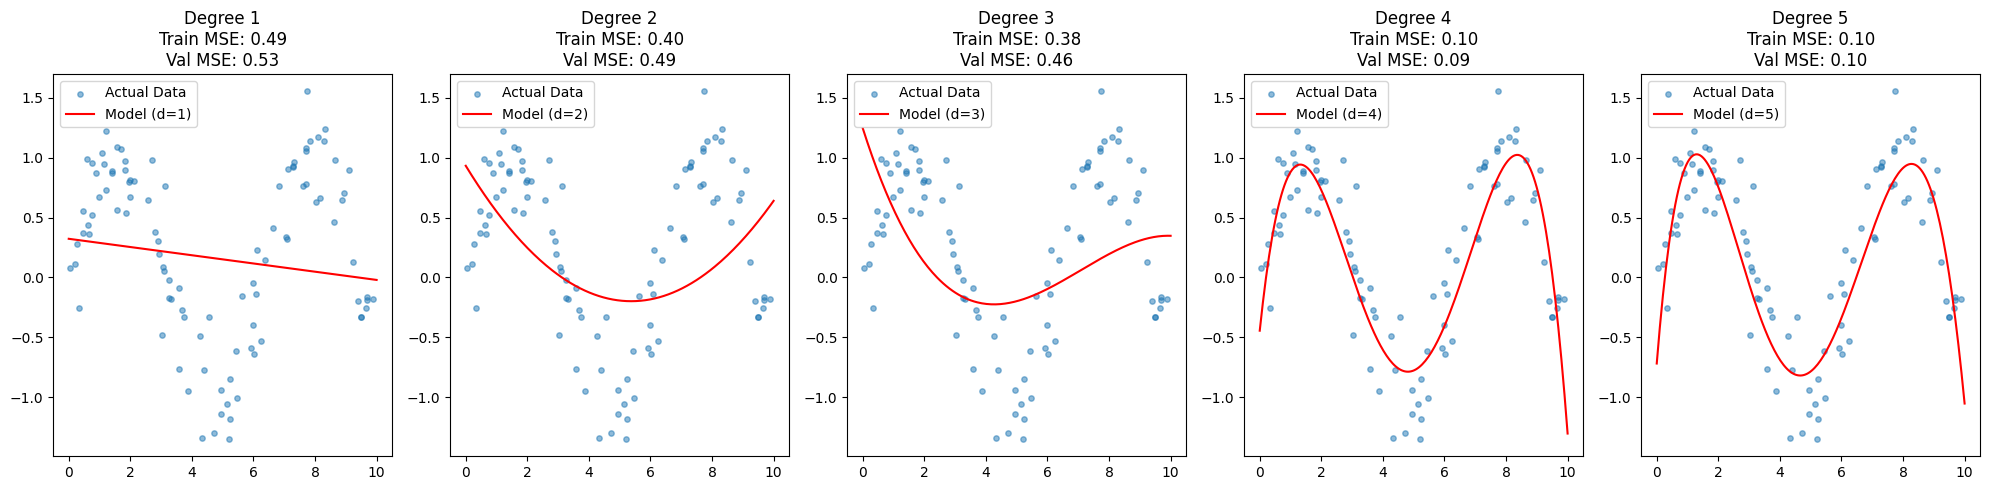

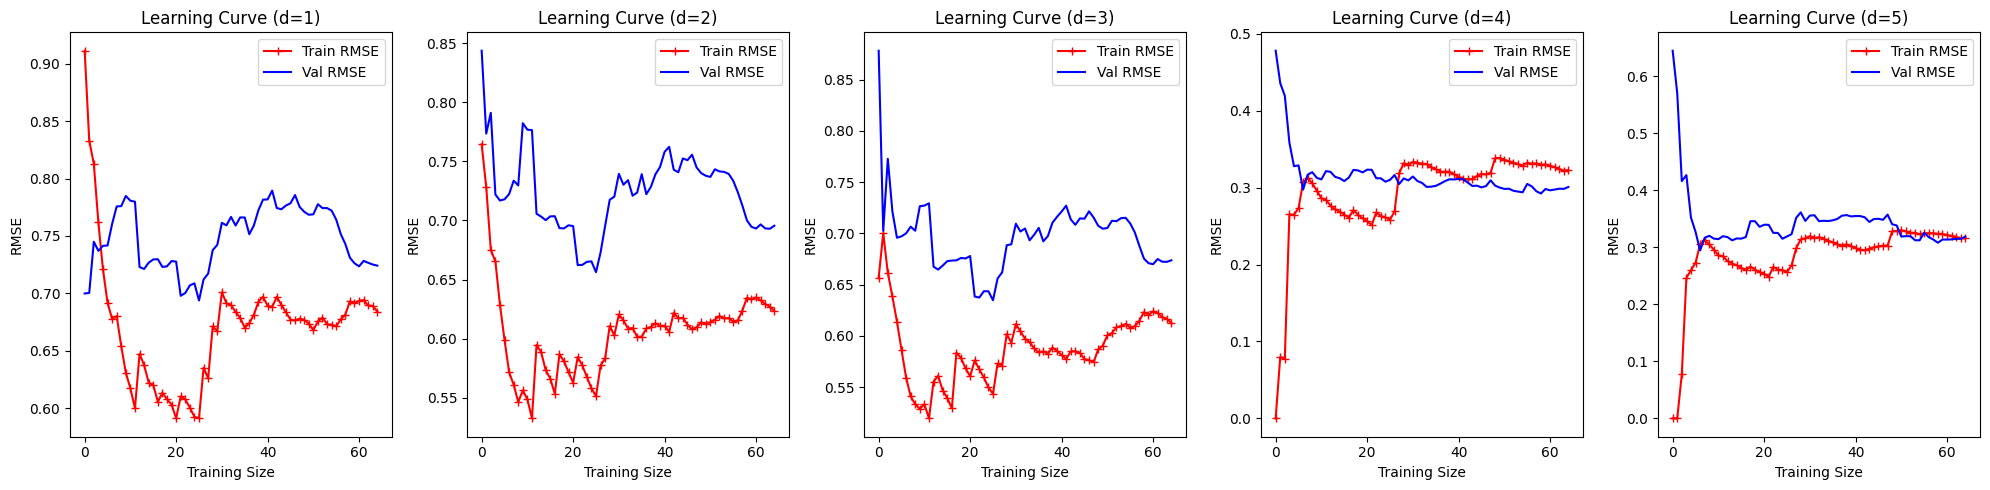

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

class DataHandler:
    @staticmethod
    def generate_data(n_samples=100):
        np.random.seed(42)
        # Generate X values from 0 to 10
        X = np.sort(np.random.rand(n_samples, 1) * 10, axis=0)
        # Sine wave + Gaussian noise
        y = np.sin(X).ravel() + np.random.normal(0, 0.3, X.shape[0])
        return X, y

    @staticmethod
    def split_data(X, y):
        return train_test_split(X, y, test_size=0.3, random_state=42)

class PolynomialModel:
    """A clean wrapper for Polynomial Regression."""
    def __init__(self, degree):
        self.degree = degree
        self.poly = PolynomialFeatures(degree=degree)
        self.model = LinearRegression()

    def fit(self, X, y):
        X_poly = self.poly.fit_transform(X)
        self.model.fit(X_poly, y)

    def predict(self, X):
        X_poly = self.poly.transform(X)
        return self.model.predict(X_poly)

    def get_mse(self, X, y):
        predictions = self.predict(X)
        return mean_squared_error(y, predictions)

class ExperimentRunner:
    """Handles the logic for running multiple degrees and plotting."""
    def __init__(self, degrees):
        self.degrees = degrees
        self.dh = DataHandler()
        self.X, self.y = self.dh.generate_data()
        self.X_train, self.X_val, self.y_train, self.y_val = self.dh.split_data(self.X, self.y)

    def run_all(self):
        fig, axes = plt.subplots(1, len(self.degrees), figsize=(20, 5))
        
        for i, d in enumerate(self.degrees):
            # 1. Train Model
            pm = PolynomialModel(degree=d)
            pm.fit(self.X_train, self.y_train)

            # 2. Compute Errors
            train_err = pm.get_mse(self.X_train, self.y_train)
            val_err = pm.get_mse(self.X_val, self.y_val)

            # 3. Plot Regression Curve
            X_range = np.linspace(0, 10, 200).reshape(-1, 1)
            y_pred = pm.predict(X_range)

            axes[i].scatter(self.X, self.y, s=15, alpha=0.5, label="Actual Data")
            axes[i].plot(X_range, y_pred, color='red', label=f"Model (d={d})")
            axes[i].set_title(f"Degree {d}\nTrain MSE: {train_err:.2f}\nVal MSE: {val_err:.2f}")
            axes[i].legend()

        plt.tight_layout()
        plt.show()

    def plot_learning_curves(self):
        plt.figure(figsize=(20, 5))
        for i, d in enumerate(self.degrees):
            plt.subplot(1, len(self.degrees), i+1)
            train_errors, val_errors = [], []
            
            # Gradually increase training set size
            for m in range(5, len(self.X_train)):
                pm = PolynomialModel(degree=d)
                pm.fit(self.X_train[:m], self.y_train[:m])
                
                train_errors.append(pm.get_mse(self.X_train[:m], self.y_train[:m]))
                val_errors.append(pm.get_mse(self.X_val, self.y_val))

            plt.plot(np.sqrt(train_errors), "r-+", label="Train RMSE")
            plt.plot(np.sqrt(val_errors), "b-", label="Val RMSE")
            plt.title(f"Learning Curve (d={d})")
            plt.xlabel("Training Size")
            plt.ylabel("RMSE")
            plt.legend()
        plt.tight_layout()
        plt.show()

# Execution
if __name__ == "__main__":
    # Use 1 for Underfitting, 3 for Good Fit, and 15 for Overfitting
    runner = ExperimentRunner(degrees=[1, 2,3,4,5]) 
    runner.run_all()
    runner.plot_learning_curves()